# **True Scepticism Versus "The Debunker Mentality"**

In [1]:
import numpy as np
import statsmodels.api as sm
from matplotlib import pyplot as plt
import scipy.stats as stats
%matplotlib inline

Let's talk a little about "skepticism" from a scientific standpoint. More simplistically, how can a scientist distinguish between statistical anomalies and 'proof' of the unexplained. It sounds complicated but most of what we'll discuss will not go beyond a very basic understanding of statistics. And there's pictures! Everyone likes pictures. Don't let math or code intimidate you if these are not things you have much experience with. The overall message here is simple and approachable regardless of background. My goal here is not to talk about 'UFOs' directly or prove something regarding them. It's to explain the scientific methodology of detecting a true phenomenon vs a collection of random anomalies.

So we're trying to make a determination if something in the world violates our current understanding. This is actually the basis of the problem that the "Scientific Method", the gold standard for proof, addresses. This is how A/B experiments are analyzed. To this end, I'm going to simulate some data (from a random number generator), to represent an A/B experiment. I want you to think of the blue data as experiences that fall well within your understanding of the world. The red data is a collection of strange experiences that we hope to categorize as either random anomalies or a true phenomenon. The y-axis is a measurement or quantification of each experience. We will give some examples in a second but understand that the point I'm making applies to any measurement. Think of this as a placeholder for a decision that we make without loss of generality..

To understand the connection between what I'm describing from the context of UFO's I've added 2 plots below the 1st that simply relabel the axis to give specific context to the more general example we're discussing:

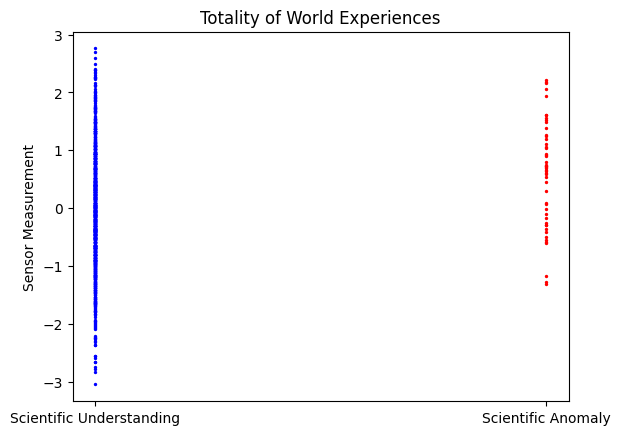

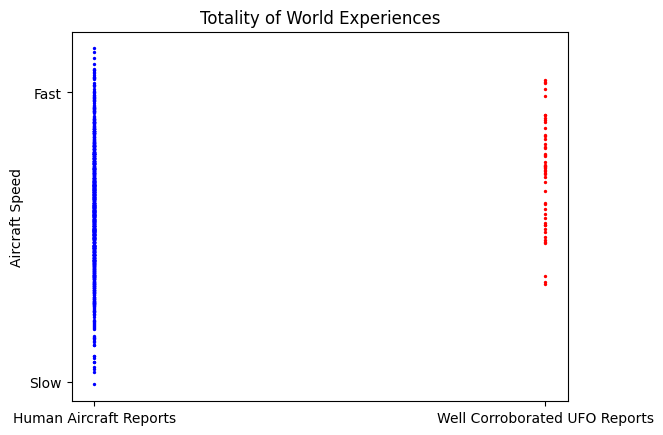

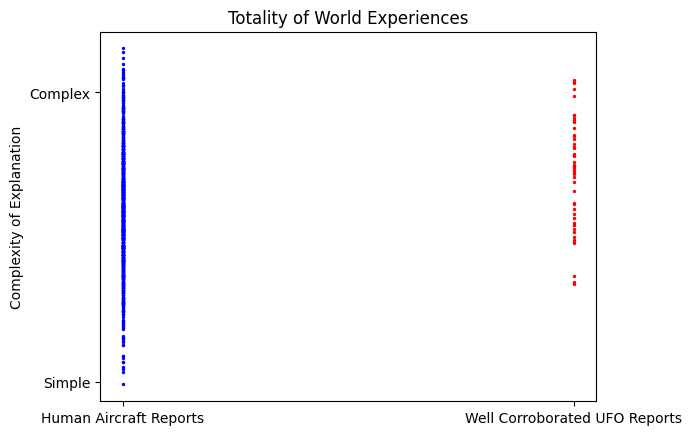

In [2]:
marker_size=2
np.random.seed(0)
N_0 = 1000
N_1 = 50
mu_1 = 0
mu_2 = .5

X_0 = np.random.normal(loc=mu_1, size=N_0)
X_1 = np.random.normal(loc=mu_2, size=N_1)

plt.figure()
plt.scatter([0]*N_0, X_0, s=marker_size, color='b', label='Scientific Understanding')
plt.scatter([1]*N_1, X_1, s=marker_size, color='r', label='Scientific Anomaly')
#plt.legend()
plt.title("Totality of World Experiences")
plt.xticks([0, 1], ['Scientific Understanding', 'Scientific Anomaly'])
plt.ylabel('Sensor Measurement')
plt.show()

plt.figure()
plt.scatter([0]*N_0, X_0, s=marker_size, color='b', label='Scientific Understanding')
plt.scatter([1]*N_1, X_1, s=marker_size, color='r', label='Scientific Anomaly')
plt.title("Totality of World Experiences")
plt.xticks([0, 1], ['Human Aircraft Reports', 'Well Corroborated UFO Reports'])
plt.ylabel('Aircraft Speed')
plt.yticks([-3, 2], ['Slow', 'Fast'])
plt.show()

plt.figure()
plt.scatter([0]*N_0, X_0, s=marker_size, color='b', label='Scientific Understanding')
plt.scatter([1]*N_1, X_1, s=marker_size, color='r', label='Scientific Anomaly')
plt.title("Totality of World Experiences")
plt.xticks([0, 1], ['Human Aircraft Reports', 'Well Corroborated UFO Reports'])
plt.yticks([-3, 2], ['Simple', 'Complex'])
plt.ylabel('Complexity of Explanation')
plt.show()

So how does the scientific method deal with this scenario? Surely scientists are "skeptical" right? Carl Sagan said, "extraordinary claims require extroardinary evidence." He was absolutely right. And the scientific method biases heavily towards assuming that any difference between treatment and control is simply the result of randomness. In specific terms, scientists conventionally assume randomness as an explanation if it was even 5% likely to be true. This is what is referred to as "confidence level". A "95% confidence level" corresponds to assuming randomness if it was at least 5% likely to explain your data.

So let's review. If a scientist observes that their experimental group (red data) has even a 5% chance of being random anomalies they do not reject their current understanding of the world (the null hypothesis). It is only if there is less than a 5% chance that randomness could explain what they saw that they would assume that the experimental data is proof of a real phenomenon.

Let's run a standard hypothesis test on our data using 99% confidence:

In [3]:
p_val = sm.stats.ttest_ind(X_0, X_1)[1]
confidence_level = .99
print ("Confidence Level: %5.2f"%(100*confidence_level))
print("TTest PValue: %5.2f"%(100*p_val))
print("Probability of Statistical Significance: %5.2f"%(100*(1 - p_val)))
print("Test for Significance: %s"%(str(confidence_level < (1 - p_val))))

Confidence Level: 99.00
TTest PValue:  0.00
Probability of Statistical Significance: 100.00
Test for Significance: True


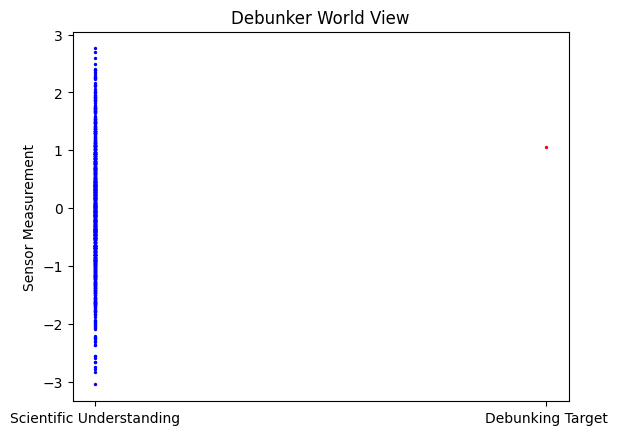

In [4]:
N_debunk=1
plt.figure()
plt.scatter([0]*N_0, X_0, s=marker_size, color='b')
plt.scatter([1]*N_debunk, X_1[:N_debunk], s=marker_size, color='r')
plt.title("Debunker World View")
plt.xticks([0, 1], ['Scientific Understanding', 'Debunking Target'])
plt.ylabel('Sensor Measurement')
plt.show()

In [5]:
p_val = sm.stats.ttest_ind(X_0, X_1[:N_debunk])[1]
print ("Confidence Level: %5.2f"%(100*confidence_level))
print("TTest PValue: %5.2f"%(100*p_val))
print("Probability of Statistical Significance: %5.2f"%(100*(1 - p_val)))
print("Test for Significance: %s"%(str(confidence_level < (1 - p_val))))

Confidence Level: 99.00
TTest PValue: 26.53
Probability of Statistical Significance: 73.47
Test for Significance: False


The debunker isolates a single measurement which we describe as the "debunking target". They then perform a hypothesis test against this target using it as the entirety of their experimental data. Unlike our result earlier, the test comes back False. This indicates that we should categorize this data-point as the result of random variation and nothing more. As I said before, main-stream science agrees with the logic given a single data-point. Unfortunately, this is rarely the case. As in our example where we tested all of the anomalies at once and rejected the null hypothesis (unlike the debunker).

Now, to demonstrate how the "smoking gun" mentality violates the scientific method we're going to perform a new test. This test operates exactly the same as a "smoking gun" would. You try to 'debunk' each point and perform a hypothesis test. You only assume a phenomenom is real if you fail to debunk each point. Hence, finding a "smoking gun" piece of evidence. Mathematically this corresponds to computing the minimum p-value across all tests performed. Simply put, you use the hardest to explain point to evaluate all of the anomalies:

In [6]:
min_p_val = 100
for k in range(len(X_1)):
  p_val = sm.stats.ttest_ind(X_0, [X_1[k]])[1]
  if p_val < min_p_val:
    min_p_val = p_val
print ("Confidence Level: %5.2f"%(100*confidence_level))
print("Minimum TTest PValue Across Anomalies: %5.2f"%(100*min_p_val))
print("Maximum Probability of Statistical Significance Across Anomalies: %5.2f"%(100*(1 - min_p_val)))
print("Sequential Test for Significance: %s"%(str(confidence_level < (1 - min_p_val))))

Confidence Level: 99.00
Minimum TTest PValue Across Anomalies:  2.25
Maximum Probability of Statistical Significance Across Anomalies: 97.75
Sequential Test for Significance: False


So the "smoking gun" approach does not agree with the Scientific Method in this case. But why? It agrees with the individual cases right?

Right, but we cannot look at our data sequentially. Otherwise it's impossible to discern any new trend. We evaluate all data-points in our experiment in a single test to draw an overall conclusion on whether randomness can explain the set of anomalies. This is why the significance level for the overall test is so much higher than the max significance level across 1-sample tests. The fact that these numbers are not the same means there is a chance at misidentifying the overall result (depending the choice of confidence level).

To visualize I've graphed the probability that the set of anomalies demonstrate a true phenomenon vs the number of points below:

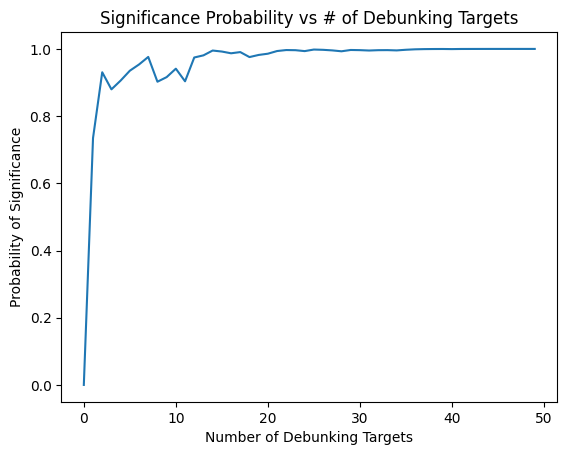

In [7]:
probs = [0] + [1 - sm.stats.ttest_ind(X_0, X_1[:k])[1] for k in range(1, N_1)]
N_debunks = [0] + list(range(1, N_1))
plt.figure()
plt.plot(N_debunks, probs)
plt.xlabel('Number of Debunking Targets')
plt.ylabel('Probability of Significance')
plt.title('Significance Probability vs # of Debunking Targets')
plt.show()

The probability increases as we add more samples to the test. Why? Because our estimate of the sample mean is becoming more accurate. To visualize this effect I've plotted the distribution of  the sample mean as we add more and more points below. Notice the distribution tightening as the number of samples increases:



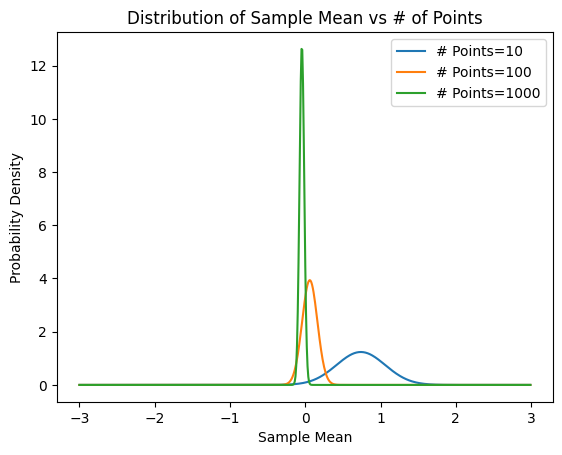

In [8]:
X_tot = X_0
x_vals = np.arange(-3, 3, .01)
N_points = [10, 100, 1000]
N_plot=len(N_points)
plt.figure()

for k in range(N_plot):
    X = X_tot[:N_points[k]]
    sample_mean = X.mean()
    sample_std = X.std() / (len(X) - 1) ** .5
    y_vals = stats.norm.pdf(x_vals, loc=sample_mean, scale=sample_std)
    plt.plot(x_vals, y_vals, label='# Points=%d'%len(X))
plt.xlabel('Sample Mean')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Distribution of Sample Mean vs # of Points')
plt.show()

So, what's the takeaway for you. My point is not that the above code demonstrates proof of UFO's in the slightest. It merely demonstrates how "debunkers" do not adhere to science. I implore you to think carefully about the difference between a high bar for truth and the logical fallacies that sequential debunking (the smoking gun test) contains. Be skeptical of singular anomalies. But think critically about whether you're using improbable explanations over and over again. Look holistically at the information available when making determinations. As you learn more about something, revaluate your understanding in a top down way. Otherwise you may find yourself at odds with the most powerful tool of humanity; the Scientific Method.